## Data of European residents traveling to Switzerland

In [2]:
# import modules
import pandas as pd
import numpy as np
import json
from pyjstat import pyjstat
import matplotlib.pyplot as plt

In [3]:
# list of European countries (here, in total 51 countries)
eu_countries = ["Albania", "Andorra", "Armenia", "Austria", "Azerbaijan",
                "Belarus", "Belgium", "Bosnia and Herzegovina", "Bulgaria",
                "Croatia", "Cyprus", "Czechia",
                "Denmark",
                "Estonia",
                "Finland", "France",
                "Georgia", "Germany", "Greece",
                "Hungary",
                "Iceland", "Ireland", "Italy",
                "Kazakhstan", "Kosovo",
                "Latvia", "Liechtenstein", "Lithuania", "Luxembourg",
                "Malta", "Moldova", "Monaco", "Montenegro",
                "Netherlands", "North Macedonia", "Norway",
                "Poland", "Portugal",
                "Romania", "Russia",
                "San Marino", "Serbia", "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland",
                "Turkey",
                "Ukraine", "United Kingdom",
                "Vatican City"]

len(eu_countries)

51

In [4]:
# read dataset: https://www.pxweb.bfs.admin.ch/pxweb/en/px-x-1003020000_102/px-x-1003020000_102/px-x-1003020000_102.px/table/tableViewLayout2/
# Hotel sector: arrivals and overnight stays of open establishments by Year, Month, Canton, Visitors' country of residence and Indicator
with open("px-x-1003020000_102_20260525-135233.json", "r", encoding="utf-8") as f:
    data = json.load(f)

dataset = pyjstat.from_json_stat(data)

dataset = dataset[0]
# eu_to_ch_df = eu_to_ch_df.dropna()

dataset.loc[:, "Visitors' country of residence"] = dataset["Visitors' country of residence"].replace("Irland", "Ireland")
dataset = dataset.rename(columns={"Month": "TIME_SEQ"})

dataset

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
0,2005,Total of the year,Switzerland,Visitors' country of residence - total,Arrivals,13802796.0
1,2005,Total of the year,Switzerland,Visitors' country of residence - total,Overnight stays,32943736.0
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
3,2005,Total of the year,Switzerland,Switzerland,Overnight stays,14622420.0
4,2005,Total of the year,Switzerland,Baltic States,Arrivals,13115.0
...,...,...,...,...,...,...
1204627,2026,December,Jura,Czechia,Overnight stays,NaN
1204628,2026,December,Jura,Ukraine,Arrivals,NaN
1204629,2026,December,Jura,Ukraine,Overnight stays,NaN
1204630,2026,December,Jura,Serbia,Arrivals,NaN


In [5]:
dataset

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
0,2005,Total of the year,Switzerland,Visitors' country of residence - total,Arrivals,13802796.0
1,2005,Total of the year,Switzerland,Visitors' country of residence - total,Overnight stays,32943736.0
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
3,2005,Total of the year,Switzerland,Switzerland,Overnight stays,14622420.0
4,2005,Total of the year,Switzerland,Baltic States,Arrivals,13115.0
...,...,...,...,...,...,...
1204627,2026,December,Jura,Czechia,Overnight stays,NaN
1204628,2026,December,Jura,Ukraine,Arrivals,NaN
1204629,2026,December,Jura,Ukraine,Overnight stays,NaN
1204630,2026,December,Jura,Serbia,Arrivals,NaN


In [6]:
dataset["Visitors' country of residence"].unique()

array(["Visitors' country of residence - total", 'Switzerland',
       'Baltic States', 'Germany', 'France', 'Italy', 'Austria',
       'United Kingdom', 'Ireland', 'Netherlands', 'Belgium',
       'Luxembourg', 'Denmark', 'Sweden', 'Norway', 'Finland', 'Spain',
       'Portugal', 'Greece', 'Turkey', 'Other European countries',
       'Liechtenstein', 'Iceland', 'Poland', 'Hungary', 'Belarus',
       'Bulgaria', 'Malta', 'Cyprus', 'Chile', 'United States', 'Canada',
       'Mexico', 'Brazil', 'Argentina', 'Central America, Caribbean',
       'Other South American countries',
       'Other Central American countries', 'Egypt',
       'Other North African countries', 'South Africa',
       'Other African countries', 'Bahrain', 'Israel', 'India', 'Japan',
       'Other South-East Asian countries', 'Qatar', 'Kuwait', 'Australia',
       'Australia, New Zealand, Oceania', 'China', 'Gulf States',
       'Hong Kong', 'Indonesia', 'South Korea', 'Malaysia', 'Philippines',
       'New Zealand, 

In [7]:
serbia_df = dataset[
    dataset["Visitors' country of residence"].isin(['Serbia', 'Serbia and Montenegro'])
][["Year", "Visitors' country of residence", "value"]].sort_values("Year")

# starting from year 2010, Serbia and Montenegro contain NaN values
# print(serbia_df)
print(serbia_df.dropna())
print(serbia_df.dropna()[["Year", "Visitors' country of residence"]].drop_duplicates().sort_values("Year"))

         Year Visitors' country of residence    value
138      2005          Serbia and Montenegro  11389.0
36798    2005          Serbia and Montenegro     29.0
36643    2005          Serbia and Montenegro     42.0
36642    2005          Serbia and Montenegro      9.0
36487    2005          Serbia and Montenegro    145.0
...       ...                            ...      ...
1164850  2026                         Serbia      5.0
1164695  2026                         Serbia     26.0
1164694  2026                         Serbia      8.0
1164539  2026                         Serbia    244.0
1164538  2026                         Serbia    109.0

[14860 rows x 3 columns]
         Year Visitors' country of residence
138      2005          Serbia and Montenegro
91398    2006          Serbia and Montenegro
146154   2007          Serbia and Montenegro
200910   2008          Serbia and Montenegro
255667   2009          Serbia and Montenegro
310439   2010                         Serbia
365194   20

In [8]:
eu_to_ch_df = dataset[dataset["Visitors' country of residence"].isin(eu_countries)]
len(eu_to_ch_df["Visitors' country of residence"].unique())

37

In [9]:
extra = ['Baltic States', 'Serbia and Montenegro', 'Other European countries']
eu_to_ch_df = dataset[dataset["Visitors' country of residence"].isin(eu_countries + extra)]
len(eu_to_ch_df["Visitors' country of residence"].unique())

40

In [10]:
eu_to_ch_df

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
3,2005,Total of the year,Switzerland,Switzerland,Overnight stays,14622420.0
4,2005,Total of the year,Switzerland,Baltic States,Arrivals,13115.0
5,2005,Total of the year,Switzerland,Baltic States,Overnight stays,32871.0
6,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0
...,...,...,...,...,...,...
1204627,2026,December,Jura,Czechia,Overnight stays,NaN
1204628,2026,December,Jura,Ukraine,Arrivals,NaN
1204629,2026,December,Jura,Ukraine,Overnight stays,NaN
1204630,2026,December,Jura,Serbia,Arrivals,NaN


In [11]:
eu_annual_total = eu_to_ch_df[
    (eu_to_ch_df["TIME_SEQ"] == "Total of the year") &
    (eu_to_ch_df["Indicator"] == "Arrivals") &
    (eu_to_ch_df["Canton"] == "Switzerland") &
    (eu_to_ch_df["Visitors' country of residence"].isin(eu_countries + ['Baltic States', 'Serbia and Montenegro', 'Other European countries']))
].groupby("Year")["value"].sum().reset_index()

print(eu_annual_total)

    Year       value
0   2005  11819832.0
1   2006  12633697.0
2   2007  13345871.0
3   2008  13845743.0
4   2009  13458421.0
5   2010  13750466.0
6   2011  13497841.0
7   2012  13275446.0
8   2013  13517247.0
9   2014  13610656.0
10  2015  13301582.0
11  2016  13524623.0
12  2017  14080437.0
13  2018  14606040.0
14  2019  14902263.0
15  2020  10139764.0
16  2021  12996859.0
17  2022  15575365.0
18  2023  16474232.0
19  2024  16732752.0
20  2025  17193300.0
21  2026         0.0


In [12]:
# Here we check year 2025 data
data_df = dataset.dropna()
data_df[(data_df["Year"]=="2025") & (data_df["Canton"]=="Switzerland") & (data_df["Indicator"]=="Arrivals")]

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
1095120,2025,Total of the year,Switzerland,Visitors' country of residence - total,Arrivals,22173712.0
1095122,2025,Total of the year,Switzerland,Switzerland,Arrivals,11119049.0
1095126,2025,Total of the year,Switzerland,Germany,Arrivals,1779401.0
1095128,2025,Total of the year,Switzerland,France,Arrivals,871032.0
1095130,2025,Total of the year,Switzerland,Italy,Arrivals,495151.0
...,...,...,...,...,...,...
1145810,2025,December,Switzerland,Slovakia,Arrivals,1287.0
1145812,2025,December,Switzerland,Slovenia,Arrivals,988.0
1145814,2025,December,Switzerland,Czechia,Arrivals,3811.0
1145816,2025,December,Switzerland,Ukraine,Arrivals,5618.0


In [13]:
data_df[(data_df["Year"]=="2025") & (data_df["TIME_SEQ"]=="Total of the year") & (data_df["Indicator"]=="Arrivals")]

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
1095120,2025,Total of the year,Switzerland,Visitors' country of residence - total,Arrivals,22173712.0
1095122,2025,Total of the year,Switzerland,Switzerland,Arrivals,11119049.0
1095126,2025,Total of the year,Switzerland,Germany,Arrivals,1779401.0
1095128,2025,Total of the year,Switzerland,France,Arrivals,871032.0
1095130,2025,Total of the year,Switzerland,Italy,Arrivals,495151.0
...,...,...,...,...,...,...
1099322,2025,Total of the year,Jura,Slovakia,Arrivals,7.0
1099324,2025,Total of the year,Jura,Slovenia,Arrivals,8.0
1099326,2025,Total of the year,Jura,Czechia,Arrivals,31.0
1099328,2025,Total of the year,Jura,Ukraine,Arrivals,13.0


In [14]:
# filter data for European residents traveling to Switzerland
# annual data
eu_to_ch_filtered_df = eu_to_ch_df[(eu_to_ch_df["TIME_SEQ"]=="Total of the year") & (eu_to_ch_df["Indicator"]=="Arrivals")]

eu_to_ch_filtered_df.head(20)

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
4,2005,Total of the year,Switzerland,Baltic States,Arrivals,13115.0
6,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0
8,2005,Total of the year,Switzerland,France,Arrivals,542502.0
10,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0
12,2005,Total of the year,Switzerland,Austria,Arrivals,149826.0
14,2005,Total of the year,Switzerland,United Kingdom,Arrivals,709155.0
16,2005,Total of the year,Switzerland,Ireland,Arrivals,25278.0
18,2005,Total of the year,Switzerland,Netherlands,Arrivals,312546.0
20,2005,Total of the year,Switzerland,Belgium,Arrivals,207644.0


In [15]:
eu_to_ch_filtered_df = eu_to_ch_filtered_df.copy()

eu_to_ch_filtered_df.loc[:, "Year"] = pd.to_numeric(
    eu_to_ch_filtered_df["Year"],
    errors="coerce"
)
eu_to_ch_arrival_2020_2026 = eu_to_ch_filtered_df[(eu_to_ch_filtered_df["Year"] >= 2020) & (eu_to_ch_filtered_df["Year"] <= 2025)]
eu_to_ch_arrival_2020_2026

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
821342,2020,Total of the year,Switzerland,Switzerland,Arrivals,7694605.0
821344,2020,Total of the year,Switzerland,Baltic States,Arrivals,NaN
821346,2020,Total of the year,Switzerland,Germany,Arrivals,885226.0
821348,2020,Total of the year,Switzerland,France,Arrivals,414385.0
821350,2020,Total of the year,Switzerland,Italy,Arrivals,198609.0
...,...,...,...,...,...,...
1099322,2025,Total of the year,Jura,Slovakia,Arrivals,7.0
1099324,2025,Total of the year,Jura,Slovenia,Arrivals,8.0
1099326,2025,Total of the year,Jura,Czechia,Arrivals,31.0
1099328,2025,Total of the year,Jura,Ukraine,Arrivals,13.0


In [16]:
print(eu_to_ch_filtered_df["Year"].dtype)
print(eu_to_ch_filtered_df["Year"].unique()[:5])
print(eu_to_ch_filtered_df["Canton"].unique()[:5])
print(eu_to_ch_filtered_df.shape)

object
[2005 2006 2007 2008 2009]
['Switzerland' 'Zurich' 'Bern' 'Lucerne' 'Uri']
(23760, 6)


In [17]:
eu_to_ch_filtered_df_to_2025 = eu_to_ch_filtered_df[(eu_to_ch_filtered_df["Year"] >= 2005) & (eu_to_ch_filtered_df["Year"] <= 2025)]
eu_to_ch_filtered_df_to_2025

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
4,2005,Total of the year,Switzerland,Baltic States,Arrivals,13115.0
6,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0
8,2005,Total of the year,Switzerland,France,Arrivals,542502.0
10,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0
...,...,...,...,...,...,...
1099322,2025,Total of the year,Jura,Slovakia,Arrivals,7.0
1099324,2025,Total of the year,Jura,Slovenia,Arrivals,8.0
1099326,2025,Total of the year,Jura,Czechia,Arrivals,31.0
1099328,2025,Total of the year,Jura,Ukraine,Arrivals,13.0


In [18]:
eu_to_ch_df = eu_to_ch_df.copy()

eu_to_ch_df.loc[:, "Year"] = pd.to_numeric(
    eu_to_ch_df["Year"],
    errors="coerce"
)

<Figure size 1400x600 with 0 Axes>

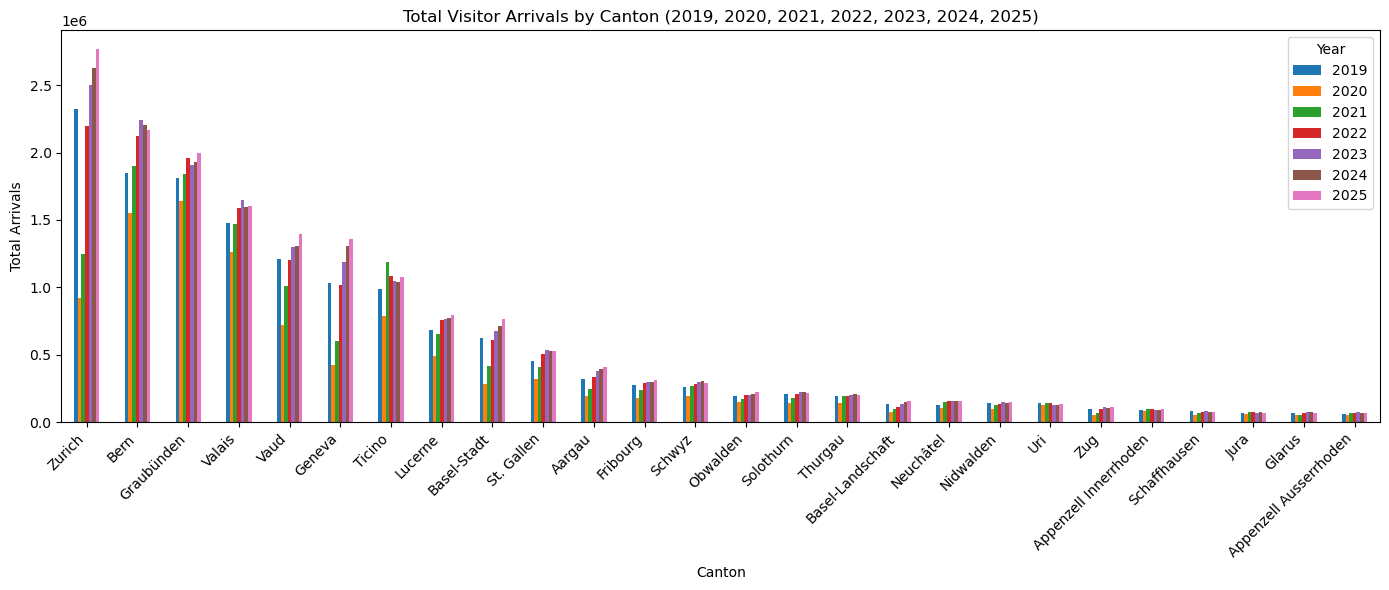

In [19]:
# plot Total Visitor Arrivals by Canton - stacked bar for 2019, 2022, 2025
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

canton_by_year = {}
for year in years:
    df = eu_to_ch_filtered_df_to_2025[
        (eu_to_ch_filtered_df_to_2025["Year"] == year) &
        (eu_to_ch_filtered_df_to_2025["TIME_SEQ"] == "Total of the year") &
        (eu_to_ch_filtered_df_to_2025["Indicator"] == "Arrivals") &
        (eu_to_ch_filtered_df_to_2025["Canton"] != "Switzerland")
    ]
    canton_by_year[year] = df.groupby("Canton")["value"].sum()

stacked_df = pd.DataFrame(canton_by_year).fillna(0)
stacked_df = stacked_df.sort_values(2025, ascending=False)

plt.figure(figsize=(14, 6))
# stacked_df.plot(kind="bar", stacked=True, figsize=(14, 6))
stacked_df.plot(kind="bar", stacked=False, figsize=(14, 6))
plt.title("Total Visitor Arrivals by Canton (2019, 2020, 2021, 2022, 2023, 2024, 2025)")
plt.xlabel("Canton")
plt.ylabel("Total Arrivals")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [20]:
eu_to_ch_filtered_df_to_2025.head(100)

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
4,2005,Total of the year,Switzerland,Baltic States,Arrivals,13115.0
6,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0
8,2005,Total of the year,Switzerland,France,Arrivals,542502.0
10,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0
...,...,...,...,...,...,...
344,2005,Total of the year,Bern,Spain,Arrivals,17047.0
346,2005,Total of the year,Bern,Portugal,Arrivals,1832.0
348,2005,Total of the year,Bern,Greece,Arrivals,2512.0
350,2005,Total of the year,Bern,Turkey,Arrivals,1380.0


In [21]:
# filter Arrivals, Total of the year, each Canton

filtered = eu_to_ch_filtered_df_to_2025[
    (eu_to_ch_filtered_df_to_2025["TIME_SEQ"] == "Total of the year") &
    (eu_to_ch_filtered_df_to_2025["Indicator"] == "Arrivals") &
    (eu_to_ch_filtered_df_to_2025["Canton"] != "Switzerland")
][["Year", "Canton", "value"]]

filtered_grouped = filtered.groupby(["Year", "Canton"])["value"].sum().reset_index()

result = {}
for year, group in filtered_grouped.groupby("Year"):
    result[int(year)] = dict(zip(group["Canton"], group["value"]))

name_fix = {
    "Zurich": "Zürich",
    "Lucerne": "Luzern",
    "Geneva": "Genève"
    # "Graubunden": "Graubünden",
    # "Neuchatel": "Neuchâtel",
}

# fix each year traget cantons names
for year in result:
    result[year] = {name_fix.get(k, k): v for k, v in result[year].items()}
    
with open("canton_annual_total_eu_visitors.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(result)

{2005: {'Aargau': 242892.0, 'Appenzell Ausserrhoden': 54339.0, 'Appenzell Innerrhoden': 75237.0, 'Basel-Landschaft': 98199.0, 'Basel-Stadt': 325548.0, 'Bern': 1587630.0, 'Fribourg': 178119.0, 'Genève': 781613.0, 'Glarus': 58559.0, 'Graubünden': 1620750.0, 'Jura': 48287.0, 'Luzern': 497219.0, 'Neuchâtel': 101415.0, 'Nidwalden': 135791.0, 'Obwalden': 176413.0, 'Schaffhausen': 59894.0, 'Schwyz': 246028.0, 'Solothurn': 153816.0, 'St. Gallen': 396568.0, 'Thurgau': 180128.0, 'Ticino': 1016211.0, 'Uri': 104193.0, 'Valais': 1245224.0, 'Vaud': 865090.0, 'Zug': 95951.0, 'Zürich': 1474718.0}, 2006: {'Aargau': 256957.0, 'Appenzell Ausserrhoden': 57729.0, 'Appenzell Innerrhoden': 83988.0, 'Basel-Landschaft': 102555.0, 'Basel-Stadt': 364638.0, 'Bern': 1691418.0, 'Fribourg': 183327.0, 'Genève': 919943.0, 'Glarus': 62424.0, 'Graubünden': 1664024.0, 'Jura': 53818.0, 'Luzern': 558834.0, 'Neuchâtel': 106247.0, 'Nidwalden': 122620.0, 'Obwalden': 206714.0, 'Schaffhausen': 63503.0, 'Schwyz': 261922.0, 'Solo

In [22]:
import geopandas as gpd

gdf = gpd.read_file("swissBOUNDARIES3D_1_5_TLM_KANTONSGEBIET.shp", encoding="utf-8")
print(gdf.columns.tolist())  # check columns
gdf = gdf.set_crs(epsg=2056)
gdf = gdf.to_crs(epsg=4326)
gdf.to_file("cantons.geojson", driver="GeoJSON")

['UUID', 'DATUM_AEND', 'DATUM_ERST', 'ERSTELL_J', 'ERSTELL_M', 'GRUND_AEND', 'HERKUNFT', 'HERKUNFT_J', 'HERKUNFT_M', 'REVISION_J', 'REVISION_M', 'REVISION_Q', 'OBJEKTART', 'KANTONSNUM', 'SEE_FLAECH', 'KANTONSFLA', 'NAME', 'ICC', 'EINWOHNERZ', 'geometry']


## European Countries GDP

In [24]:
# read dataset: https://ec.europa.eu/eurostat/databrowser/view/sdg_10_10/default/table?lang=en
# Purchasing power adjusted GDP per capita
gdp_ppp_df = pd.read_csv("ppp_adj_gdp_per_capita.csv")

# drop unused columns
gdp_ppp_df = gdp_ppp_df.drop(columns={"STRUCTURE", "STRUCTURE_ID", "STRUCTURE_NAME", "freq", "Time frequency", "Analytical categories for purchasing power parities (PPPs) calculation (based on COICOP18)",
                                      "geo", "Time", "Observation value", "Observation status (Flag) V2 structure", "Confidentiality status (flag)"})

In [25]:
# check countries with GDP values that are (e)estimated or (p)provisional
gdp_ppp_df[gdp_ppp_df["OBS_FLAG"].isin(["e", "p"])].head()

,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
25,CV_VI_HAB,Coefficient of variation of volume indices of ...,GDP,PC,Percentage,Euro area – 20 countries (2023-2025),2025,42.3,p,NaN
26,CV_VI_HAB,Coefficient of variation of volume indices of ...,GDP,PC,Percentage,Euro area – 21 countries (from 2026),2025,42.8,p,NaN
52,CV_VI_HAB,Coefficient of variation of volume indices of ...,GDP,PC,Percentage,European Union - 27 countries (from 2020),2025,40.1,p,NaN
77,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2024,16700.0,p,NaN
103,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Austria,2025,48900.0,p,NaN


In [26]:
# rename column Geopolitical entity (reporting) as country
# drop columns OBS_FLAG and CONF_STATUS
gdp_ppp_df = gdp_ppp_df.rename(columns={"Geopolitical entity (reporting)":"country"}).drop(columns={"OBS_FLAG", "CONF_STATUS"})
gdp_ppp_df["country"] = gdp_ppp_df["country"].replace("Türkiye", "Turkey")

eu_gdp_ppp_df = gdp_ppp_df[gdp_ppp_df["country"].isin(eu_countries)]
eu_gdp_ppp_df.head()
eu_gdp_ppp_df["country"].unique()

array(['Albania', 'Austria', 'Bosnia and Herzegovina', 'Belgium',
       'Bulgaria', 'Switzerland', 'Cyprus', 'Czechia', 'Germany',
       'Denmark', 'Estonia', 'Greece', 'Spain', 'Finland', 'France',
       'Croatia', 'Hungary', 'Ireland', 'Iceland', 'Italy', 'Lithuania',
       'Luxembourg', 'Latvia', 'Montenegro', 'North Macedonia', 'Malta',
       'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Serbia',
       'Sweden', 'Slovenia', 'Slovakia', 'Turkey', 'United Kingdom'],
      dtype=object)

In [27]:
eu_gdp_ppp_df

,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,country,TIME_PERIOD,OBS_VALUE
53,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2000,3300.0
54,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2001,3700.0
55,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2002,4000.0
56,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2003,4200.0
57,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2004,4600.0
...,...,...,...,...,...,...,...,...
2109,VI_PPS_EU27_2020_HAB,Volume indices of real expenditure per capita ...,GDP,PC,Percentage,United Kingdom,2020,102.0
2110,VI_PPS_EU27_2020_HAB,Volume indices of real expenditure per capita ...,GDP,PC,Percentage,United Kingdom,2021,100.0
2111,VI_PPS_EU27_2020_HAB,Volume indices of real expenditure per capita ...,GDP,PC,Percentage,United Kingdom,2022,103.0
2112,VI_PPS_EU27_2020_HAB,Volume indices of real expenditure per capita ...,GDP,PC,Percentage,United Kingdom,2023,99.0


In [28]:
eu_to_ch_filtered_df.loc[:, "Year"] = eu_to_ch_filtered_df["Year"].astype(int)

eu_gdp_ppp_filtered_df = eu_gdp_ppp_df[eu_gdp_ppp_df["Purchasing power parities indicator"]=="Real expenditure per capita (in PPS_EU27_2020)"]

eu_gdp_and_to_ch_df = pd.merge(eu_to_ch_filtered_df, eu_gdp_ppp_filtered_df,
                               left_on=["Visitors' country of residence", "Year"], right_on=["country", "TIME_PERIOD"],
                               how="left")

eu_gdp_and_to_ch_df
eu_gdp_and_to_ch_df = eu_gdp_and_to_ch_df.drop(columns={"country", "TIME_PERIOD"})

eu_gdp_and_to_ch_df = eu_gdp_and_to_ch_df.dropna()
eu_gdp_and_to_ch_df = eu_gdp_and_to_ch_df.rename(columns={"value": "num_of_visitors", "OBS_VALUE": "gdp_pps"})

eu_gdp_and_to_ch_df.head(50)
# from here we can see that each country's GDP per capita (PPS) values are duplicated because we merge the monthly number of visitors from European countries to Switzerland with annual GDP 

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,num_of_visitors,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,gdp_pps
0,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,34300.0
2,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,26800.0
3,2005,Total of the year,Switzerland,France,Arrivals,542502.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,25000.0
4,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,24700.0
5,2005,Total of the year,Switzerland,Austria,Arrivals,149826.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,28500.0
6,2005,Total of the year,Switzerland,United Kingdom,Arrivals,709155.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,26900.0
7,2005,Total of the year,Switzerland,Ireland,Arrivals,25278.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,33100.0
8,2005,Total of the year,Switzerland,Netherlands,Arrivals,312546.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,30900.0
9,2005,Total of the year,Switzerland,Belgium,Arrivals,207644.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,27200.0
10,2005,Total of the year,Switzerland,Luxembourg,Arrivals,35309.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,56300.0


In [29]:
eu_gdp_and_to_ch_df["Visitors' country of residence"].unique()

array(['Switzerland', 'Germany', 'France', 'Italy', 'Austria',
       'United Kingdom', 'Ireland', 'Netherlands', 'Belgium',
       'Luxembourg', 'Denmark', 'Sweden', 'Norway', 'Finland', 'Spain',
       'Portugal', 'Greece', 'Turkey', 'Iceland', 'Poland', 'Hungary',
       'Bulgaria', 'Croatia', 'Romania', 'Slovakia', 'Slovenia',
       'Czechia', 'Malta', 'Cyprus', 'Estonia', 'Latvia', 'Lithuania',
       'Serbia'], dtype=object)

In [30]:
len(eu_gdp_and_to_ch_df["Visitors' country of residence"].unique())

33

In [31]:
eu_gdp_and_to_ch_df.describe()

,num_of_visitors,gdp_pps
count,1.772000e+04,17720.000000
mean,3.107576e+04,30788.910835
std,3.058879e+05,14489.313785
min,0.000000e+00,7900.000000
25%,1.300000e+02,20900.000000
50%,6.500000e+02,28700.000000
75%,4.073000e+03,36100.000000
max,1.094049e+07,99300.000000


In [32]:
# sum up all the 
eu_gdp_and_to_ch_annual_df = eu_gdp_and_to_ch_df.groupby(["Year", "Visitors' country of residence", "gdp_pps"])["num_of_visitors"].sum().reset_index()
eu_gdp_and_to_ch_annual_df

,Year,Visitors' country of residence,gdp_pps,num_of_visitors
0,2005,Austria,28500.0,299652.0
1,2005,Belgium,27200.0,415288.0
2,2005,Bulgaria,8300.0,24496.0
3,2005,Croatia,12700.0,17872.0
4,2005,Czechia,18100.0,50490.0
...,...,...,...,...
652,2025,Romania,32400.0,110814.0
653,2025,Slovakia,31100.0,35850.0
654,2025,Slovenia,37700.0,28340.0
655,2025,Spain,38100.0,532258.0


In [33]:
eu_gdp_and_to_ch_annual_plot_df_2019_2024 = eu_gdp_and_to_ch_annual_df[(eu_gdp_and_to_ch_annual_df["Year"] >= 2019) & (eu_gdp_and_to_ch_annual_df["Year"] <= 2024)]
eu_gdp_and_to_ch_annual_plot_df_2019_2024 = eu_gdp_and_to_ch_annual_plot_df_2019_2024[["Year", "Visitors' country of residence", "num_of_visitors", "gdp_pps"]].drop_duplicates()

eu_gdp_and_to_ch_annual_plot_df_2019_2024

,Year,Visitors' country of residence,num_of_visitors,gdp_pps
432,2019,Austria,376224.0,39300.0
433,2019,Belgium,416598.0,36900.0
434,2019,Bulgaria,30174.0,17400.0
435,2019,Croatia,24626.0,21300.0
436,2019,Cyprus,13342.0,28900.0
...,...,...,...,...
625,2024,Spain,533320.0,36400.0
626,2024,Sweden,139852.0,44400.0
627,2024,Switzerland,21880980.0,60500.0
628,2024,Turkey,168716.0,28600.0


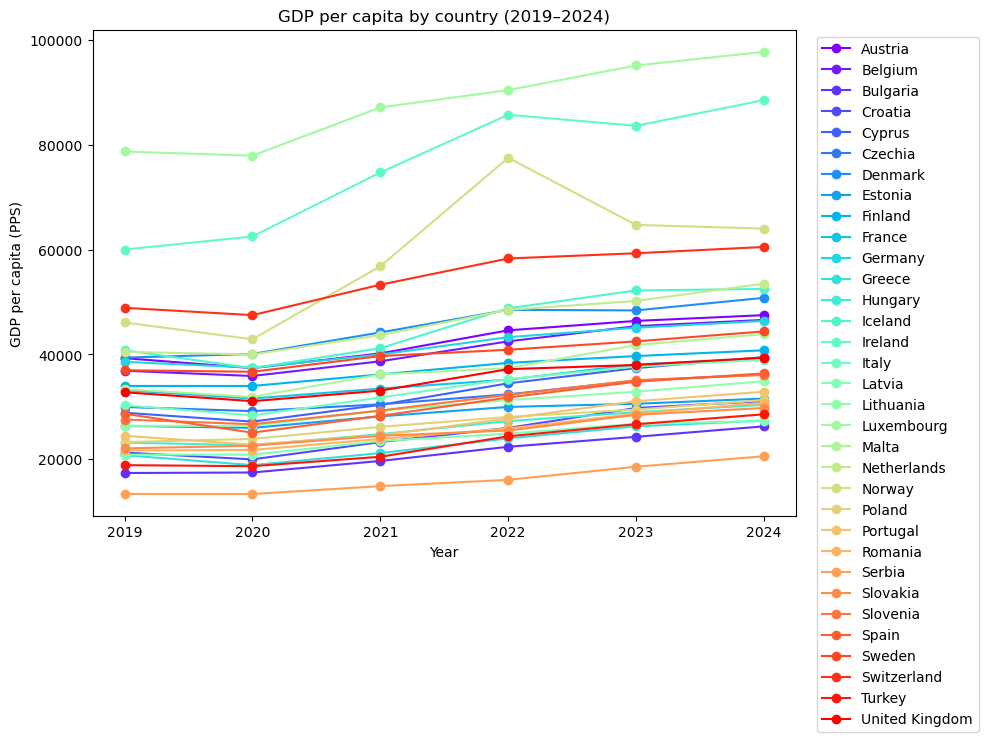

In [34]:
plt.figure(figsize=(10,7))

countries = eu_gdp_and_to_ch_annual_plot_df_2019_2024["Visitors' country of residence"].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(countries)))

for i, country in enumerate(countries):    
    
    country_data = eu_gdp_and_to_ch_annual_plot_df_2019_2024[eu_gdp_and_to_ch_annual_plot_df_2019_2024["Visitors' country of residence"] == country]
    
    plt.plot(
        country_data["Year"],
        country_data["gdp_pps"],
        marker="o",
        label=country,
        color=colors[i]
    )

plt.xlabel("Year")
plt.ylabel("GDP per capita (PPS)")
plt.title("GDP per capita by country (2019–2024)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [35]:
eu_gdp_and_to_ch_annual_plot_df_2019_2025 = eu_gdp_and_to_ch_annual_df[(eu_gdp_and_to_ch_annual_df["Year"] >= 2019) & (eu_gdp_and_to_ch_annual_df["Year"] <= 2025)]
eu_gdp_and_to_ch_annual_plot_df_2019_2025 = eu_gdp_and_to_ch_annual_plot_df_2019_2025[["Year", "Visitors' country of residence", "num_of_visitors", "gdp_pps"]].drop_duplicates()

eu_gdp_and_to_ch_annual_plot_df_2019_2025

,Year,Visitors' country of residence,num_of_visitors,gdp_pps
432,2019,Austria,376224.0,39300.0
433,2019,Belgium,416598.0,36900.0
434,2019,Bulgaria,30174.0,17400.0
435,2019,Croatia,24626.0,21300.0
436,2019,Cyprus,13342.0,28900.0
...,...,...,...,...
652,2025,Romania,110814.0,32400.0
653,2025,Slovakia,35850.0,31100.0
654,2025,Slovenia,28340.0,37700.0
655,2025,Spain,532258.0,38100.0


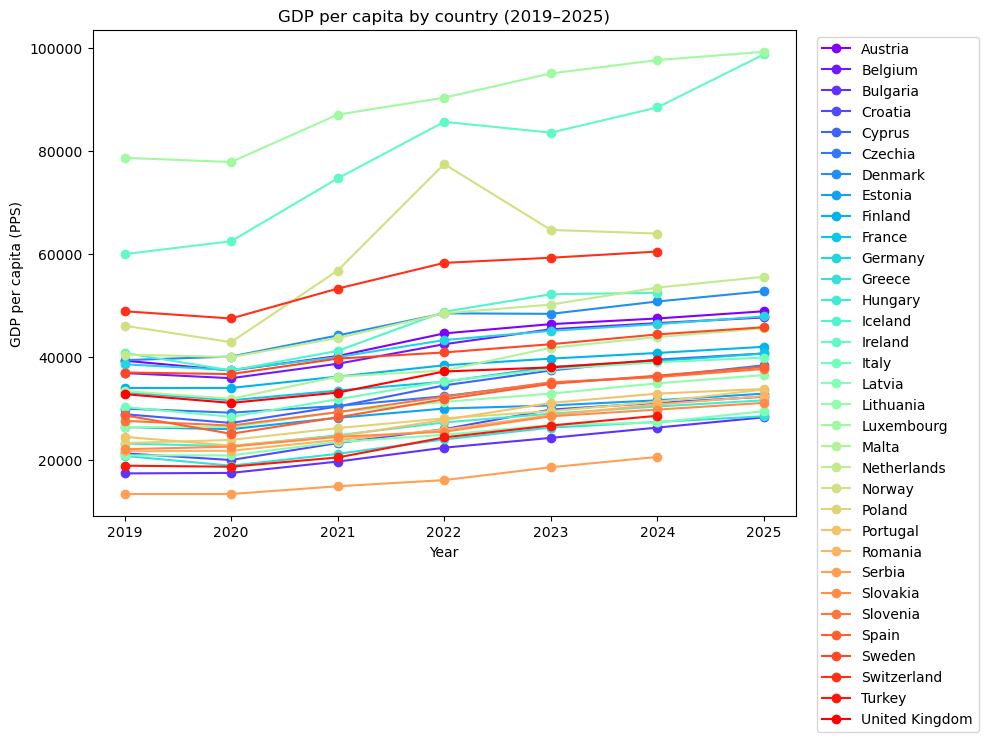

In [36]:
plt.figure(figsize=(10,7))

countries = eu_gdp_and_to_ch_annual_plot_df_2019_2025["Visitors' country of residence"].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(countries)))

for i, country in enumerate(countries):    
    
    country_data = eu_gdp_and_to_ch_annual_plot_df_2019_2025[eu_gdp_and_to_ch_annual_plot_df_2019_2025["Visitors' country of residence"] == country]
    
    plt.plot(
        country_data["Year"],
        country_data["gdp_pps"],
        marker="o",
        label=country,
        color=colors[i]
    )

plt.xlabel("Year")
plt.ylabel("GDP per capita (PPS)")
plt.title("GDP per capita by country (2019–2025)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

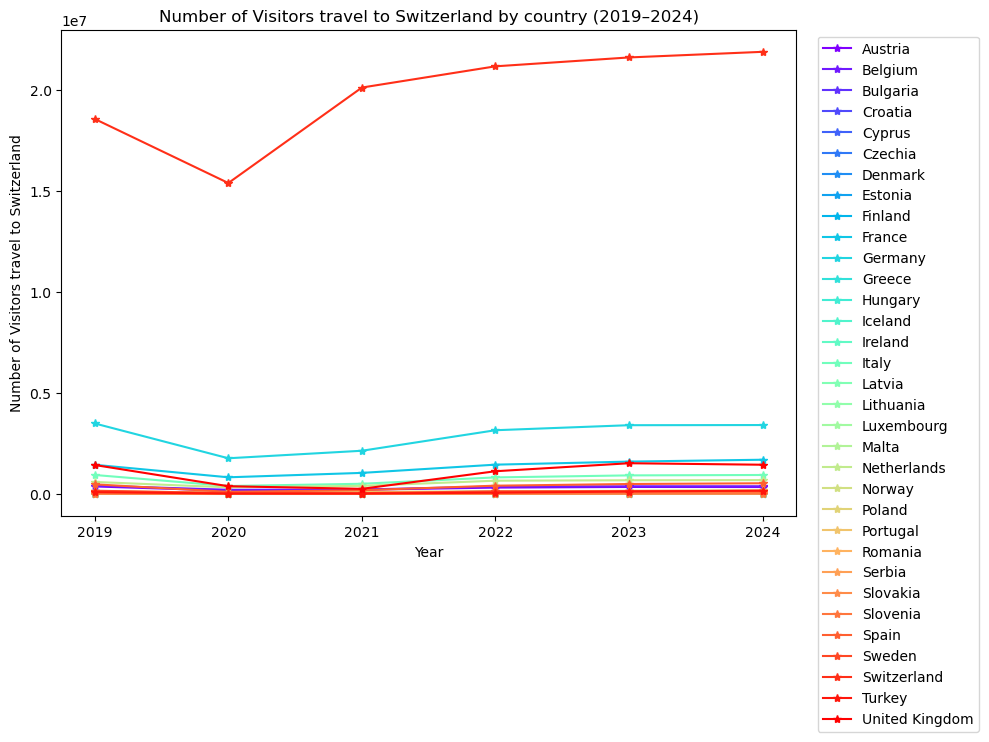

In [37]:
# set plot size
plt.figure(figsize=(10,7))

# get each country data 
for i, country in enumerate(countries):    

    # filter out data for the target country
    country_data = eu_gdp_and_to_ch_annual_plot_df_2019_2024[eu_gdp_and_to_ch_annual_plot_df_2019_2024["Visitors' country of residence"] == country]

    # plot yearly number of visitors from target country to Switzerland
    plt.plot(
        country_data["Year"],
        country_data["num_of_visitors"],
        marker="*",
        label=country,
        color=colors[i]
    )


# set plot labels and annotations
plt.xlabel("Year")
plt.ylabel("Number of Visitors travel to Switzerland")
plt.title("Number of Visitors travel to Switzerland by country (2019–2024)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# plot
plt.tight_layout()
plt.show()

In [38]:
eu_gdp_and_to_ch_annual_plot_df_2019_2024.head()

,Year,Visitors' country of residence,num_of_visitors,gdp_pps
432,2019,Austria,376224.0,39300.0
433,2019,Belgium,416598.0,36900.0
434,2019,Bulgaria,30174.0,17400.0
435,2019,Croatia,24626.0,21300.0
436,2019,Cyprus,13342.0,28900.0


In [39]:
eu_gdp_and_to_ch_annual_plot_df_2019_2025.head()

,Year,Visitors' country of residence,num_of_visitors,gdp_pps
432,2019,Austria,376224.0,39300.0
433,2019,Belgium,416598.0,36900.0
434,2019,Bulgaria,30174.0,17400.0
435,2019,Croatia,24626.0,21300.0
436,2019,Cyprus,13342.0,28900.0


### Distance

In [41]:
import requests
from geopy.distance import geodesic

response = requests.get("https://restcountries.com/v3.1/all?fields=name,latlng")
countries = response.json()

In [42]:
for c in countries:
    if c["name"]["common"] == "Switzerland":
        print(c)
        break

{'name': {'common': 'Switzerland', 'official': 'Swiss Confederation', 'nativeName': {'fra': {'official': 'Confédération suisse', 'common': 'Suisse'}, 'gsw': {'official': 'Schweizerische Eidgenossenschaft', 'common': 'Schweiz'}, 'ita': {'official': 'Confederazione Svizzera', 'common': 'Svizzera'}, 'roh': {'official': 'Confederaziun svizra', 'common': 'Svizra'}}}, 'latlng': [47.0, 8.0]}


In [43]:
switzerland = (47.0, 8.0) # according to the above data

result = {}
for c in countries:
    name = c["name"]["common"]
    latlng = c.get("latlng", [])
    if latlng:
        # calculate the distance of each available countries(in the data) between Switzerland
        dist = geodesic(switzerland, (latlng[0], latlng[1])).km
        result[name] = {
            "lat": latlng[0],
            "long": latlng[1],
            "distance_km": round(dist, 1)
        }

with open("countries_distance.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(f"Total {len(result)} countries")

Total 250 countries


In [44]:
with open("countries_distance.json", "r", encoding="utf-8") as f:
    countries_distance_data = json.load(f)

# convert to data frame
df = pd.DataFrame(countries_distance_data)
print(df.shape)
print(df.head())

(3, 250)
                Anguilla  Guatemala       Gambia  Mexico  Malawi  \
lat            18.250000      15.50    13.466667    23.0   -13.5   
long          -63.166667     -90.25   -16.566667  -102.0    34.0   
distance_km  7126.300000    9374.20  4366.200000  9571.6  7185.0   

             Pitcairn Islands  Argentina          Guam  Bulgaria     Dominica  \
lat                -25.066667      -34.0     13.466667      43.0    15.416667   
long              -130.100000      -64.0    144.783333      25.0   -61.333333   
distance_km      15602.000000    11493.0  12051.600000    1408.8  7206.900000   

             ...  Lesotho  Uruguay  Burkina Faso   India  Philippines  \
lat          ...    -29.5    -33.0          13.0    20.0         13.0   
long         ...     28.5    -56.0          -2.0    77.0        122.0   
distance_km  ...   8718.9  10928.3        3883.8  6827.7      10696.0   

             Central African Republic   Sudan  Guinea-Bissau  \
lat                               7.

In [45]:
print(df.shape)
print(df.columns[:5])  # first 5 columns
print(df.index[:5])    # first 5 rows
print(df.iloc[:3, :3])

(3, 250)
Index(['Anguilla', 'Guatemala', 'Gambia', 'Mexico', 'Malawi'], dtype='object')
Index(['lat', 'long', 'distance_km'], dtype='object')
                Anguilla  Guatemala       Gambia
lat            18.250000      15.50    13.466667
long          -63.166667     -90.25   -16.566667
distance_km  7126.300000    9374.20  4366.200000


In [46]:
# test
df.loc["distance_km", "Anguilla"]   # 7126.3
df.loc["distance_km", "Guatemala"]  # 9374.2

# get all countries distance to 
distances_data_df = df.loc["distance_km", eu_countries]
print(distances_data_df)
print(len(distances_data_df)) # 51
# print(len(eu_countries)) # 51

# the closest
print(distances_data_df.idxmin(), distances_data_df.min())

# the farthest
print(distances_data_df.idxmax(), distances_data_df.max())

Albania                   1168.7
Andorra                    717.2
Armenia                   3060.8
Austria                    406.0
Azerbaijan                3226.0
Belarus                   1574.6
Belgium                    517.2
Bosnia and Herzegovina     848.9
Bulgaria                  1408.8
Croatia                    614.6
Cyprus                    2473.2
Czechia                    633.8
Denmark                   1010.8
Estonia                   1789.5
Finland                   2190.6
France                     473.7
Georgia                   2851.9
Germany                    450.8
Greece                    1443.0
Hungary                    911.8
Iceland                   2540.1
Ireland                   1322.9
Italy                      599.8
Kazakhstan                4329.1
Kosovo                    1145.2
Latvia                    1604.5
Liechtenstein              120.0
Lithuania                 1489.1
Luxembourg                 334.6
Malta                     1337.9
Moldova   

In [47]:
eu_data_df = data_df[(data_df["TIME_SEQ"]=="Total of the year") & (data_df["Canton"]=="Switzerland") & (data_df["Indicator"]=="Arrivals")]
eu_data_df_filtered = eu_data_df[eu_data_df["Visitors' country of residence"].isin(eu_countries)]
eu_data_df_filtered

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
6,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0
8,2005,Total of the year,Switzerland,France,Arrivals,542502.0
10,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0
12,2005,Total of the year,Switzerland,Austria,Arrivals,149826.0
...,...,...,...,...,...,...
1095266,2025,Total of the year,Switzerland,Slovakia,Arrivals,17925.0
1095268,2025,Total of the year,Switzerland,Slovenia,Arrivals,14170.0
1095270,2025,Total of the year,Switzerland,Czechia,Arrivals,55989.0
1095272,2025,Total of the year,Switzerland,Ukraine,Arrivals,42720.0


In [48]:
distances_df = distances_data_df.reset_index()
distances_df.columns = ["Visitors' country of residence", "distance_km"]

print(distances_df.head())

  Visitors' country of residence  distance_km
0                        Albania       1168.7
1                        Andorra        717.2
2                        Armenia       3060.8
3                        Austria        406.0
4                     Azerbaijan       3226.0


In [49]:
distances_df["Visitors' country of residence"].unique

<bound method Series.unique of 0                    Albania
1                    Andorra
2                    Armenia
3                    Austria
4                 Azerbaijan
5                    Belarus
6                    Belgium
7     Bosnia and Herzegovina
8                   Bulgaria
9                    Croatia
10                    Cyprus
11                   Czechia
12                   Denmark
13                   Estonia
14                   Finland
15                    France
16                   Georgia
17                   Germany
18                    Greece
19                   Hungary
20                   Iceland
21                   Ireland
22                     Italy
23                Kazakhstan
24                    Kosovo
25                    Latvia
26             Liechtenstein
27                 Lithuania
28                Luxembourg
29                     Malta
30                   Moldova
31                    Monaco
32                Montenegro
33          

In [50]:
# merge
merged = eu_data_df_filtered.merge(
    distances_df,
    on="Visitors' country of residence",
    how="left"
)

print(merged)
print(merged.shape)

     Year           TIME_SEQ       Canton Visitors' country of residence  \
0    2005  Total of the year  Switzerland                    Switzerland   
1    2005  Total of the year  Switzerland                        Germany   
2    2005  Total of the year  Switzerland                         France   
3    2005  Total of the year  Switzerland                          Italy   
4    2005  Total of the year  Switzerland                        Austria   
..    ...                ...          ...                            ...   
742  2025  Total of the year  Switzerland                       Slovakia   
743  2025  Total of the year  Switzerland                       Slovenia   
744  2025  Total of the year  Switzerland                        Czechia   
745  2025  Total of the year  Switzerland                        Ukraine   
746  2025  Total of the year  Switzerland                         Serbia   

    Indicator      value  distance_km  
0    Arrivals  6573945.0          0.0  
1    Ar

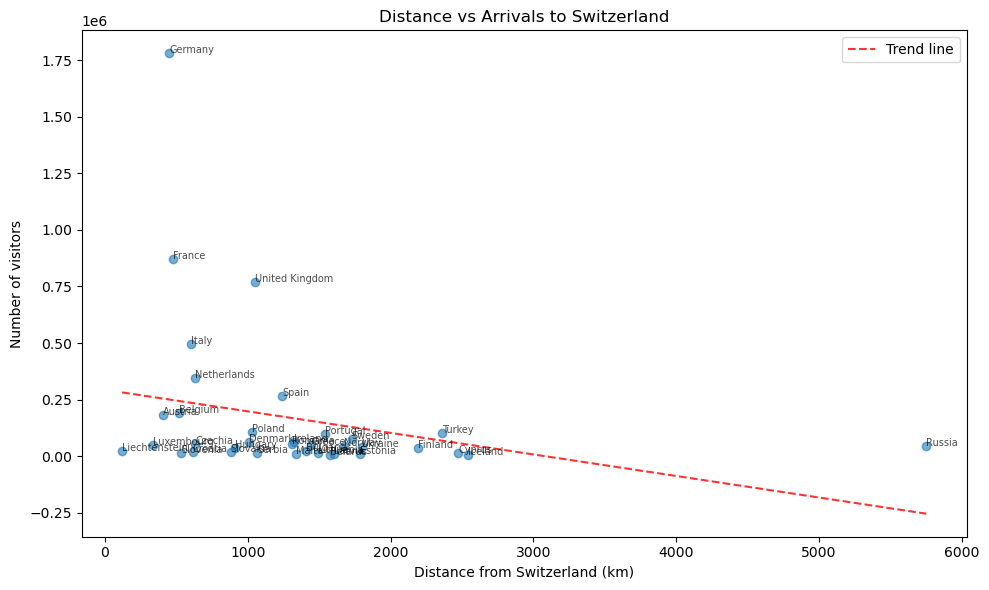

Correlation coefficient: -0.2738


In [51]:
import matplotlib.pyplot as plt
import numpy as np

# not inlclude Switzerland, take year 2025 as example
plot_df = merged[(merged["distance_km"] > 0) & (merged["Year"]=="2025")].copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(plot_df["distance_km"], plot_df["value"], alpha=0.6)

for _, row in plot_df.iterrows():
    ax.annotate(row["Visitors' country of residence"], 
                (row["distance_km"], row["value"]),
                fontsize=7, alpha=0.7)

# trend line
z = np.polyfit(plot_df["distance_km"], plot_df["value"], 1)
p = np.poly1d(z)
x_line = np.linspace(plot_df["distance_km"].min(), plot_df["distance_km"].max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.8, label="Trend line")

ax.set_xlabel("Distance from Switzerland (km)")
ax.set_ylabel("Number of visitors")
ax.set_title("Distance vs Arrivals to Switzerland")
ax.legend()
plt.tight_layout()
plt.show()

# correlation coefficient
corr = plot_df["distance_km"].corr(plot_df["value"])
print(f"Correlation coefficient: {corr:.4f}")

In [55]:
# filter
eu_to_ch_filtered_df_to_2025 = eu_to_ch_filtered_df_to_2025.copy()
eu_to_ch_filtered_df_to_2025_filtered = eu_to_ch_filtered_df_to_2025[
    (eu_to_ch_filtered_df_to_2025["TIME_SEQ"] == "Total of the year") &
    (eu_to_ch_filtered_df_to_2025["Canton"] == "Switzerland") &
    (eu_to_ch_filtered_df_to_2025["Indicator"] == "Arrivals")
].copy()

# convert Year column to numeric
eu_to_ch_filtered_df_to_2025["Year"] = pd.to_numeric(
    eu_to_ch_filtered_df_to_2025["Year"],
    errors="coerce"
)

eu_gdp_and_to_ch_df["Year"] = pd.to_numeric(
    eu_gdp_and_to_ch_df["Year"],
    errors="coerce"
)

# merge
eu_gdp_and_to_ch_df_merged = eu_gdp_and_to_ch_df.merge(
    eu_to_ch_filtered_df_to_2025,
    on=["Visitors' country of residence", "Year"],
    how="left"
)

eu_gdp_and_to_ch_df_merged

,Year,TIME_SEQ_x,Canton_x,Visitors' country of residence,Indicator_x,num_of_visitors,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,gdp_pps,TIME_SEQ_y,Canton_y,Indicator_y,value
0,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,34300.0,Total of the year,Switzerland,Arrivals,6573945.0
1,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,34300.0,Total of the year,Zurich,Arrivals,606391.0
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,34300.0,Total of the year,Bern,Arrivals,1018120.0
3,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,34300.0,Total of the year,Lucerne,Arrivals,279426.0
4,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,34300.0,Total of the year,Uri,Arrivals,46632.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478435,2025,Total of the year,Jura,Czechia,Arrivals,31.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,38400.0,Total of the year,Vaud,Arrivals,3916.0
478436,2025,Total of the year,Jura,Czechia,Arrivals,31.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,38400.0,Total of the year,Valais,Arrivals,4599.0
478437,2025,Total of the year,Jura,Czechia,Arrivals,31.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,38400.0,Total of the year,Neuchâtel,Arrivals,230.0
478438,2025,Total of the year,Jura,Czechia,Arrivals,31.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,38400.0,Total of the year,Geneva,Arrivals,6302.0


In [ ]:
# check the difference between countries names
countries_gdp = set(eu_gdp_and_to_ch_df["Visitors' country of residence"].unique())
countries_data = set(data_df_filtered["Visitors' country of residence"].unique())
print(countries_gdp)
print(countries_data)

print("in countries_gdp data：", countries_gdp - countries_data)
print("in countries_data data：", countries_data - countries_gdp)

In [ ]:
print(eu_gdp_and_to_ch_df["Visitors' country of residence"].unique())

In [ ]:
print(data_df_filtered[data_df_filtered["Visitors' country of residence"].isin(eu_countries)]["Visitors' country of residence"].unique())

In [ ]:
print("gdp years:", sorted(eu_gdp_and_to_ch_df["Year"].unique()))
print("data years:", sorted(data_df_filtered["Year"].unique()))

In [ ]:
eu_gdp_and_to_ch_df_merged

In [ ]:
with open("eu_gdp_and_to_ch_df_merged.json", "w", encoding="utf-8") as f:
    json.dump(eu_gdp_and_to_ch_df_merged.to_dict("records"), f, ensure_ascii=False, indent=2)

In [ ]:
with open("eu_gdp_and_to_ch_df_merged.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(df.head())

In [ ]:
# drop na
tmp = df[['Year',
          "Visitors' country of residence",
          'gdp_pps',
          'num_of_visitors']].dropna()

# correlation each year
corr_by_year = (
    tmp.groupby('Year')
       .apply(
           lambda x: x['gdp_pps'].corr(x['num_of_visitors']),
           include_groups=False
       )
       .reset_index(name='corr_gdp_visitors')
)

print(corr_by_year)

In [ ]:
df_filtered = df[['Year',
                  "Visitors' country of residence",
                  'gdp_pps',
                  'num_of_visitors']].dropna()

# keep 2020~2025
df_filtered = df_filtered[
    (df_filtered['Year'] >= 2020) &
    (df_filtered['Year'] <= 2025)
]

plt.figure(figsize=(12,7))

# each country line plot
for country in df_filtered["Visitors' country of residence"].unique():

    country_data = df_filtered[
        df_filtered["Visitors' country of residence"] == country
    ].sort_values('Year')

    plt.plot(
        country_data['gdp_pps'],          # X-axis GDP
        country_data['num_of_visitors'],  # Y-axis Visitors
        marker='o',
        label=country
    )

plt.title('GDP vs Visitors to Switzerland (2020-2025)')
plt.xlabel('GDP per capita (PPS)')
plt.ylabel('Number of Visitors')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
print(eu_gdp_and_to_ch_df_merged.columns.tolist())

In [ ]:
print(eu_gdp_and_to_ch_df_merged["Canton_x"].unique())
print(eu_gdp_and_to_ch_df_merged["Canton_y"].unique())
print(eu_gdp_and_to_ch_df_merged["Indicator_x"].unique())
print(eu_gdp_and_to_ch_df_merged["Indicator_y"].unique())

In [ ]:
eu_gdp_and_to_ch_df_merged = eu_gdp_and_to_ch_df_merged.drop(columns=["Canton_y", "Indicator_y", "Canton_x", "Month", "TIME_SEQ"])
eu_gdp_and_to_ch_df_merged = eu_gdp_and_to_ch_df_merged.rename(columns={"Indicator_x": "Indicator"})

print(eu_gdp_and_to_ch_df_merged.columns.tolist())
print(eu_gdp_and_to_ch_df_merged.head())

In [ ]:
eu_gdp_and_to_ch_df_merged # final eu_gdp_and_to_ch_df_merged

In [ ]:
years_to_plot = list(range(2019, 2026))

plot_df = eu_gdp_and_to_ch_df_merged[
    eu_gdp_and_to_ch_df_merged["Year"].isin(years_to_plot)
].dropna(subset=["gdp_pps"])

print(f"plot_df rows: {len(plot_df)}")

fig, ax = plt.subplots(figsize=(12, 6))

for country, group in plot_df.groupby("Visitors' country of residence"):
    group = group.sort_values("Year")
    ax.plot(group["Year"], group["gdp_pps"], marker="o", label=country)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(x))))

ax.set_xlabel("Year")
ax.set_ylabel("GDP PPS")
ax.set_title("GDP per capita (PPS) - 2020 to 2026")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
print(merged[["Year", "Visitors' country of residence", "distance_km", "value"]].to_dict("records"))
countries_distances_vs_visitors = merged[["Year", "Visitors' country of residence", "distance_km", "value"]].to_dict("records")

In [ ]:
with open("countries_distances_vs_visitors.json", "w", encoding="utf-8") as f:
    json.dump(countries_distances_vs_visitors, f, ensure_ascii=False, indent=2)